<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

## Работа с данными

In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer


df = pd.read_excel("data_problems_translated.xlsx")[['problem_text', 'topic']].dropna().reset_index(drop=True)
pd.DataFrame(df).head()

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


In [2]:
labels_sorted = sorted(df['topic'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id2label = {i: lbl for lbl, i in label2id.items()}

df['topic'] = df['topic'].map(label2id).astype(int)

pd.DataFrame(df).head()

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,5
1,( b) Will the statement of the previous challe...,5
2,The quadratic three-member graph with the coef...,6
3,Can you draw on the surface of Rubik's cube a ...,0
4,"Dima, who came from Vrunlandia, said that ther...",3


In [3]:
num_labels = len(labels_sorted)
num_labels, labels_sorted

(7,
 ['combinatorics',
  'dirichlet',
  'geometry',
  'graphs',
  'invariant',
  'number_theory',
  'polynoms'])

In [11]:
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['topic']
)

In [12]:
class ClfExcelDataset(Dataset):
    def __init__(self, frame, tokenizer, text_col="problem_text" , label_col="topic", max_len=256):
        self.frame = frame
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_col = label_col
        self.max_len = max_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        text = str(row[self.text_col])
        label = int(row[self.label_col])
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [13]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig


class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: str, num_labels: int):
        super().__init__()

        self.config = AutoConfig.from_pretrained(base_transformer_model)
        self.backbone = AutoModel.from_pretrained(base_transformer_model, config=self.config)

        # YOUR CODE: create additional layers for classfication
        hidden_size = self.config.hidden_size
        self.num_labels = num_labels

        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_labels)
        )


    def forward(self, input_ids, attention_mask=None, labels=None):
        # YOUR CODE: propagate inputs through the model. Return dict with logits
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        # Берём embedding первого токена [CLS]
        pooled_output = outputs.last_hidden_state[:, 0, :]

        # Пропускаем через классификатор
        logits = self.classifier(pooled_output)

        # Вычисляем loss, если заданы метки
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"logits": logits, "loss": loss}


### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [14]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [15]:
import copy
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

def train_transformer(transformer_model, freeze_backbone=True):

    # Копируем модель (мелкая копия)
    model = copy.copy(transformer_model)

    train_dataset = model.train_dataset
    val_dataset = model.val_dataset

    # Заморозка backbone при необходимости
    if freeze_backbone:
        freeze_backbone_function(model)

    # Гиперпараметры
    lr = getattr(model, "lr", 2e-5)
    num_epochs = getattr(model, "num_epochs", 20)
    batch_size = getattr(model, "train_batch_size", 8)

    # Девайс
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Оптимизатор
    optimizer = AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=lr
    )

    # Лоадеры
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # История
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": []
    }

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss = outputs["loss"]
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        model.eval()
        val_loss_total = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                labels=labels)

                val_loss = outputs["loss"]
                val_loss_total += val_loss.item()

                logits = outputs["logits"]
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss_total / len(val_loader)
        val_accuracy = correct / total

        history["val_loss"].append(avg_val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train_loss: {avg_train_loss:.4f} | "
            f"val_loss: {avg_val_loss:.4f} | "
            f"val_acc: {val_accuracy:.4f}"
        )

    return model, history

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

Дообучение 1: с замороженным backbone

In [27]:
rubert_tiny_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(rubert_tiny_name)

train_dataset = ClfExcelDataset(train_df, tokenizer)
val_dataset = ClfExcelDataset(val_df, tokenizer)

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [29]:
rubert_tiny_transformer_model_frozen = TransformerClassificationModel(
    rubert_tiny_name, num_labels=num_labels
)
rubert_tiny_transformer_model_frozen.train_dataset = train_dataset
rubert_tiny_transformer_model_frozen.val_dataset = val_dataset
rubert_tiny_transformer_model_frozen.num_epochs = 35

rubert_tiny_finetuned_with_freezed_backbone, loss_history_true_freeze_backbone = train_transformer(rubert_tiny_transformer_model_frozen, freeze_backbone=True)

Epoch 1/35 | train_loss: 1.7345 | val_loss: 1.6289 | val_acc: 0.4535
Epoch 2/35 | train_loss: 1.5997 | val_loss: 1.5513 | val_acc: 0.4535
Epoch 3/35 | train_loss: 1.5404 | val_loss: 1.5055 | val_acc: 0.4554
Epoch 4/35 | train_loss: 1.4997 | val_loss: 1.4677 | val_acc: 0.4554
Epoch 5/35 | train_loss: 1.4654 | val_loss: 1.4341 | val_acc: 0.4573
Epoch 6/35 | train_loss: 1.4366 | val_loss: 1.4039 | val_acc: 0.4763
Epoch 7/35 | train_loss: 1.4088 | val_loss: 1.3764 | val_acc: 0.4991
Epoch 8/35 | train_loss: 1.3883 | val_loss: 1.3518 | val_acc: 0.5199
Epoch 9/35 | train_loss: 1.3598 | val_loss: 1.3295 | val_acc: 0.5275
Epoch 10/35 | train_loss: 1.3465 | val_loss: 1.3092 | val_acc: 0.5294
Epoch 11/35 | train_loss: 1.3242 | val_loss: 1.2906 | val_acc: 0.5332
Epoch 12/35 | train_loss: 1.3105 | val_loss: 1.2739 | val_acc: 0.5294
Epoch 13/35 | train_loss: 1.2943 | val_loss: 1.2588 | val_acc: 0.5332
Epoch 14/35 | train_loss: 1.2823 | val_loss: 1.2449 | val_acc: 0.5351
Epoch 15/35 | train_loss: 1.2

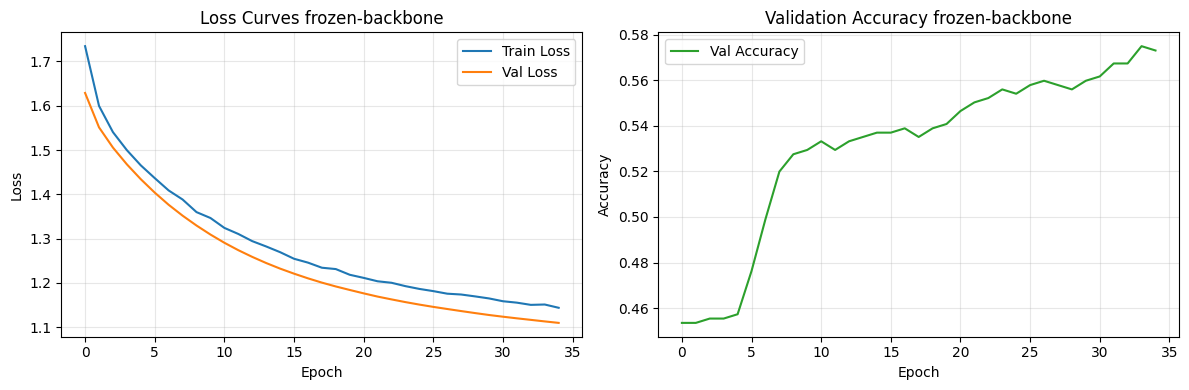

In [30]:
import matplotlib.pyplot as plt

hist = loss_history_true_freeze_backbone

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["train_loss"], label="Train Loss", color="#1f77b4")
axes[0].plot(hist["val_loss"], label="Val Loss", color="#ff7f0e")
axes[0].set_title("Loss Curves frozen-backbone", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist["val_accuracy"], label="Val Accuracy", color="#2ca02c")
axes[1].set_title("Validation Accuracy frozen-backbone", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


Лосс медленно монотонно падает. Требуется много эпох для обучения.

Дообучение 2: с размороженным backbone

In [33]:
rubert_tiny_transformer_model_full = TransformerClassificationModel(
    rubert_tiny_name, num_labels=num_labels
)
rubert_tiny_transformer_model_full.train_dataset = train_dataset
rubert_tiny_transformer_model_full.val_dataset = val_dataset
rubert_tiny_transformer_model_full.num_epochs = 4

rubert_tiny_full_finetuned, loss_history_false_freeze_backbone = train_transformer(rubert_tiny_transformer_model_full, freeze_backbone=False)

Epoch 1/4 | train_loss: 1.2870 | val_loss: 1.0321 | val_acc: 0.6053
Epoch 2/4 | train_loss: 1.0165 | val_loss: 0.9445 | val_acc: 0.6338
Epoch 3/4 | train_loss: 0.9020 | val_loss: 0.9274 | val_acc: 0.6243
Epoch 4/4 | train_loss: 0.8211 | val_loss: 0.9107 | val_acc: 0.6376


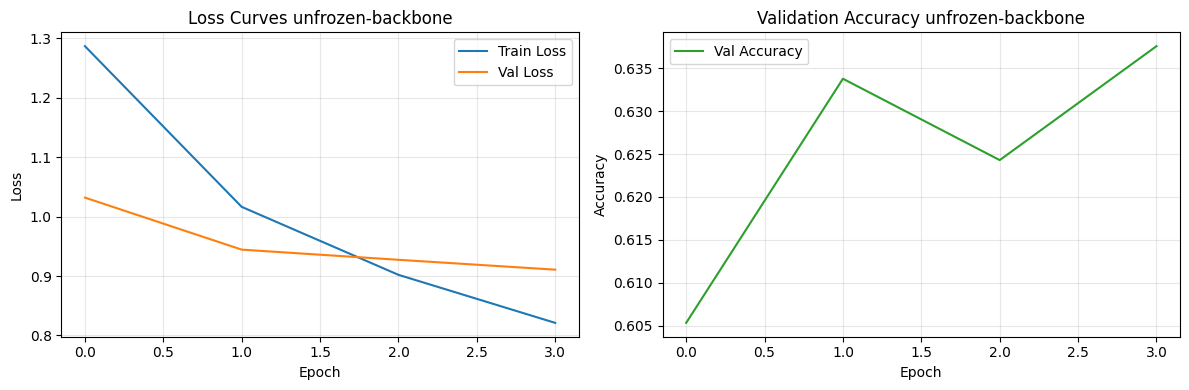

In [34]:
hist = loss_history_false_freeze_backbone


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["train_loss"], label="Train Loss", color="#1f77b4")
axes[0].plot(hist["val_loss"], label="Val Loss", color="#ff7f0e")
axes[0].set_title("Loss Curves unfrozen-backbone", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist["val_accuracy"], label="Val Accuracy", color="#2ca02c")
axes[1].set_title("Validation Accuracy unfrozen-backbone", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Лосс падает гораздо быстрее и ниже. Нужно намного меньше эпох, иначе зафиксировано сильное переобучение (4 вместо >35). Лучшая метрика - 0.65

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [18]:
mathbert_name = "tbs17/MathBert"
tokenizer = AutoTokenizer.from_pretrained(mathbert_name)

train_dataset = ClfExcelDataset(train_df, tokenizer)
val_dataset = ClfExcelDataset(val_df, tokenizer)

Обучение tbs17/MathBert с замороженным backbone

In [19]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'

mathbert_model_frozen = TransformerClassificationModel(mathbert_name, num_labels=num_labels)
mathbert_model_frozen.train_dataset = train_dataset
mathbert_model_frozen.val_dataset = val_dataset

mathbert_finetuned_frozen, mathbert_loss_history_true_freeze_backbone = train_transformer(mathbert_model_frozen, freeze_backbone=True)

Epoch 1/20 | train_loss: 1.7137 | val_loss: 1.5298 | val_acc: 0.4478
Epoch 2/20 | train_loss: 1.5549 | val_loss: 1.4667 | val_acc: 0.4516
Epoch 3/20 | train_loss: 1.5072 | val_loss: 1.4128 | val_acc: 0.4630
Epoch 4/20 | train_loss: 1.4450 | val_loss: 1.3677 | val_acc: 0.4839
Epoch 5/20 | train_loss: 1.4071 | val_loss: 1.3327 | val_acc: 0.4915
Epoch 6/20 | train_loss: 1.3734 | val_loss: 1.3017 | val_acc: 0.4991
Epoch 7/20 | train_loss: 1.3421 | val_loss: 1.2774 | val_acc: 0.5104
Epoch 8/20 | train_loss: 1.3203 | val_loss: 1.2537 | val_acc: 0.5161
Epoch 9/20 | train_loss: 1.2934 | val_loss: 1.2380 | val_acc: 0.5161
Epoch 10/20 | train_loss: 1.2720 | val_loss: 1.2198 | val_acc: 0.5256
Epoch 11/20 | train_loss: 1.2527 | val_loss: 1.2063 | val_acc: 0.5313
Epoch 12/20 | train_loss: 1.2457 | val_loss: 1.1956 | val_acc: 0.5313
Epoch 13/20 | train_loss: 1.2343 | val_loss: 1.1847 | val_acc: 0.5313
Epoch 14/20 | train_loss: 1.2180 | val_loss: 1.1761 | val_acc: 0.5313
Epoch 15/20 | train_loss: 1.2

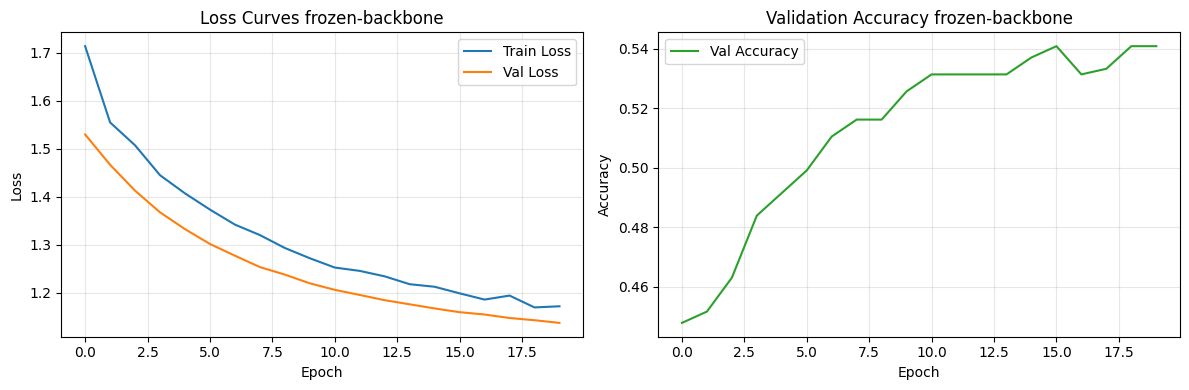

In [21]:
hist = mathbert_loss_history_true_freeze_backbone


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["train_loss"], label="Train Loss", color="#1f77b4")
axes[0].plot(hist["val_loss"], label="Val Loss", color="#ff7f0e")
axes[0].set_title("Loss Curves frozen-backbone", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist["val_accuracy"], label="Val Accuracy", color="#2ca02c")
axes[1].set_title("Validation Accuracy frozen-backbone", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Стабильное, но медленное обучение. Лучшая метрика = 0.54, модель обучается, но не достигает высокого качества.


Обучение tbs17/MathBert с размороженным backbone

In [25]:
mathbert_model_full = TransformerClassificationModel(mathbert_name, num_labels=num_labels)
mathbert_model_full.train_dataset = train_dataset
mathbert_model_full.val_dataset = val_dataset
mathbert_model_full.num_epochs = 4

mathbert_finetuned_full, mathbert_loss_history_false_freeze_backbone = train_transformer(mathbert_model_full, freeze_backbone=False)

Epoch 1/4 | train_loss: 1.1421 | val_loss: 0.9645 | val_acc: 0.6129
Epoch 2/4 | train_loss: 0.8520 | val_loss: 1.0206 | val_acc: 0.6034
Epoch 3/4 | train_loss: 0.6785 | val_loss: 1.0884 | val_acc: 0.5712
Epoch 4/4 | train_loss: 0.5623 | val_loss: 1.2796 | val_acc: 0.5787


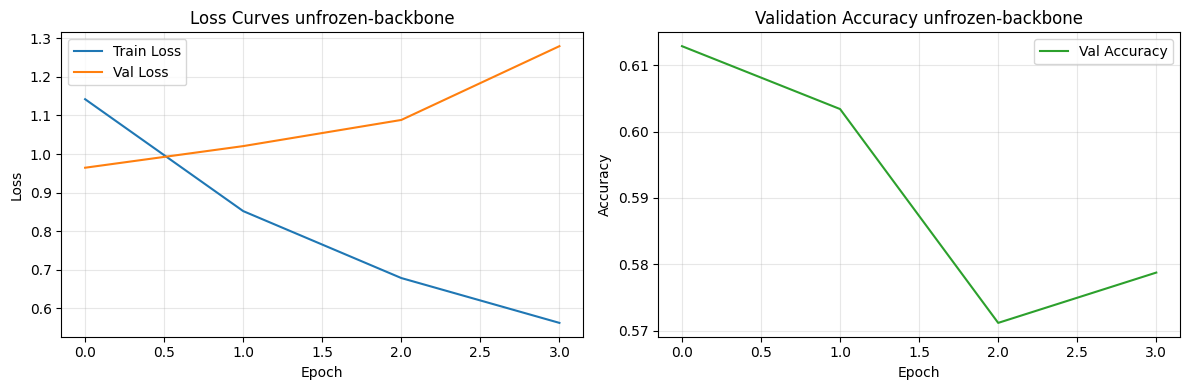

In [26]:
hist = mathbert_loss_history_false_freeze_backbone


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["train_loss"], label="Train Loss", color="#1f77b4")
axes[0].plot(hist["val_loss"], label="Val Loss", color="#ff7f0e")
axes[0].set_title("Loss Curves unfrozen-backbone", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist["val_accuracy"], label="Val Accuracy", color="#2ca02c")
axes[1].set_title("Validation Accuracy unfrozen-backbone", fontsize=12)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Быстро переобучается, лучшая метрика = 0.6129.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
import matplotlib.pyplot as plt
import torch
from typing import List

def draw_first_layer_attention_maps(attention_head_ids: List, text: str, model):
    # Токенизация текста
    inputs = model.tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    # Перемещаем на устройство модели
    device = next(model.parameters()).device
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

    # Получаем внимания
    model.eval()
    with torch.no_grad():
        outputs = model.bert(input_ids, attention_mask=attention_mask, output_attentions=True)
        attentions = outputs.attentions

    # Берем первый слой внимания
    first_layer = attentions[0].squeeze(0)  # (num_heads, seq_len, seq_len)

    # Получаем токены для подписей
    tokens = model.tokenizer.convert_ids_to_tokens(input_ids[0])

    # Создаем subplot для каждой головы
    fig, axes = plt.subplots(1, len(attention_head_ids), figsize=(5*len(attention_head_ids), 4))

    if len(attention_head_ids) == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        # Берем матрицу внимания для головы
        attention_map = first_layer[head_id].cpu().numpy()

        # Отрисовываем heatmap
        im = axes[i].imshow(attention_map, cmap='viridis')
        axes[i].set_title(f'Head {head_id}')
        axes[i].set_xticks(range(len(tokens)))
        axes[i].set_yticks(range(len(tokens)))
        axes[i].set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
        axes[i].set_yticklabels(tokens, fontsize=8)

        plt.colorbar(im, ax=axes[i])

    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [80]:
test_texts = [
    train_df.iloc[105]['problem_text'],
    train_df.iloc[118]['problem_text'],
    train_df.iloc[130]['problem_text']
]

print("Короткие тексты для анализа:")
for i, text in enumerate(test_texts):
    print(f"{i+1}. {text}")

Короткие тексты для анализа:
1. Fix the equation.
2. Prove that
3. (b) n = 5?


Анализ не дообученнной MathBERT

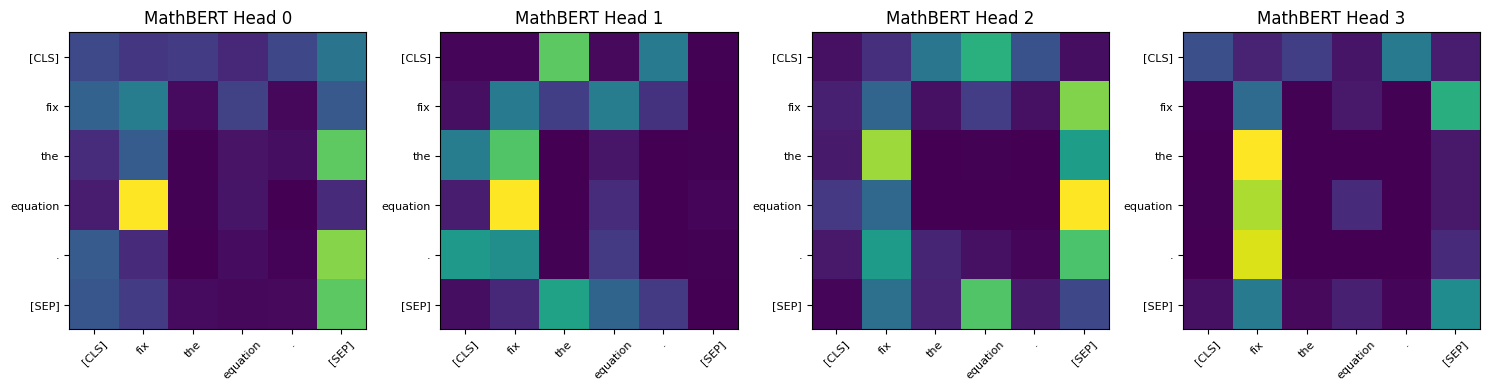

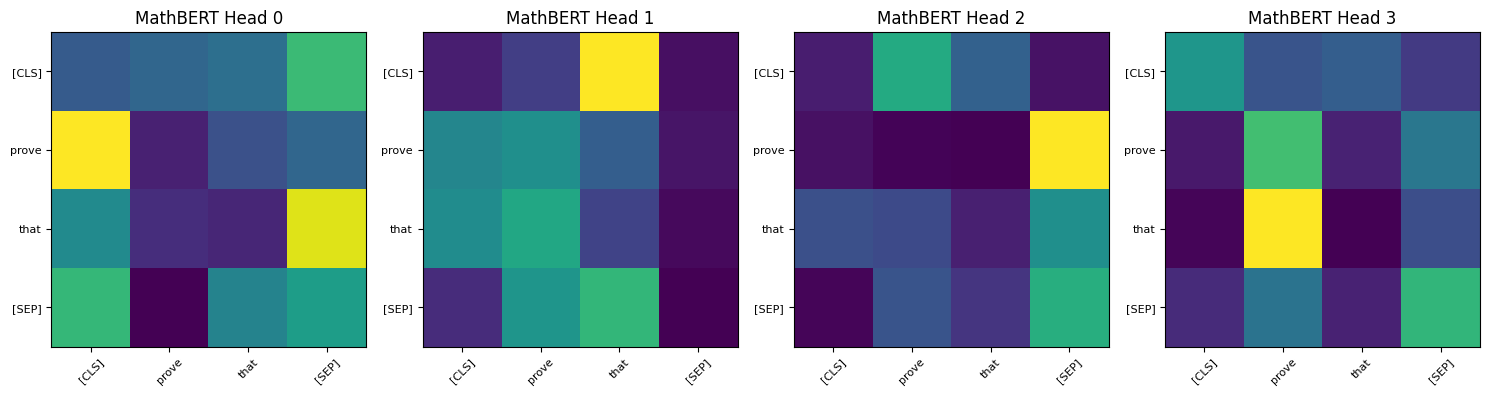

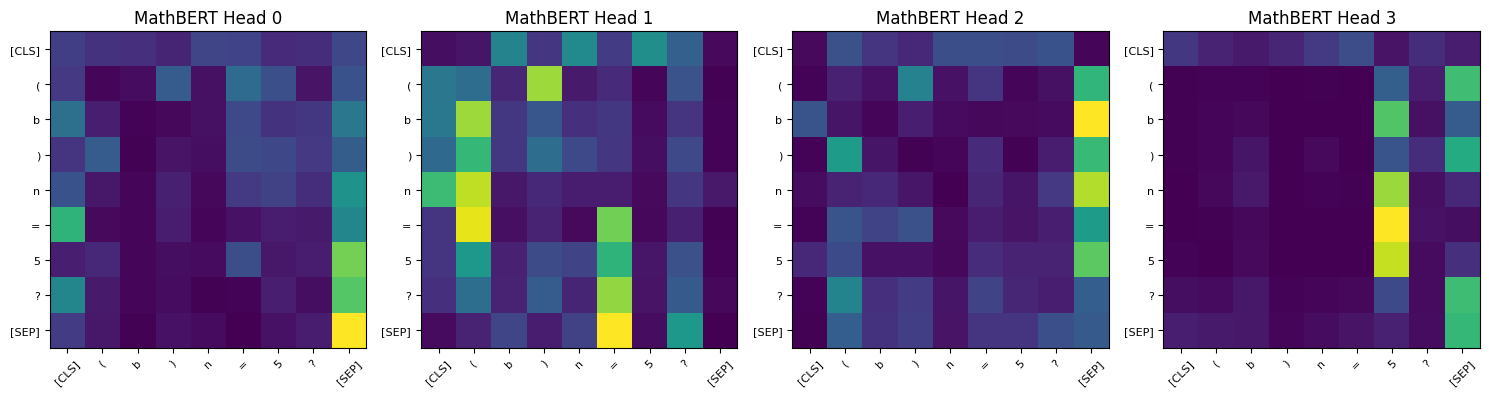

In [78]:
mathbert_tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")
mathbert_model = TransformerClassificationModel("tbs17/MathBERT", num_labels=num_labels)

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(mathbert_model.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = mathbert_model.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())  # Тоже на CPU

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'MathBERT Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()


Анализ RuBERT-Tiny  

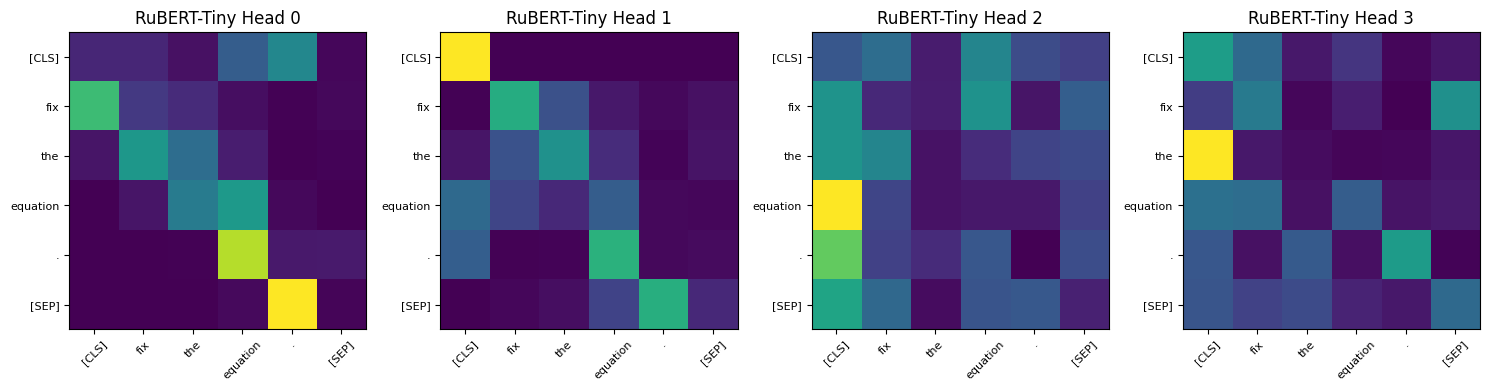

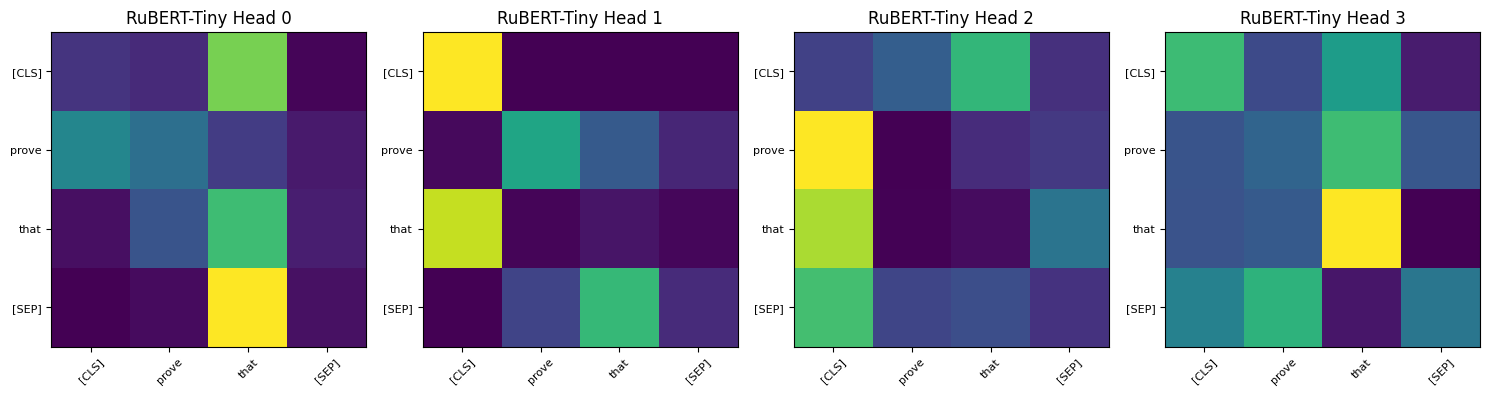

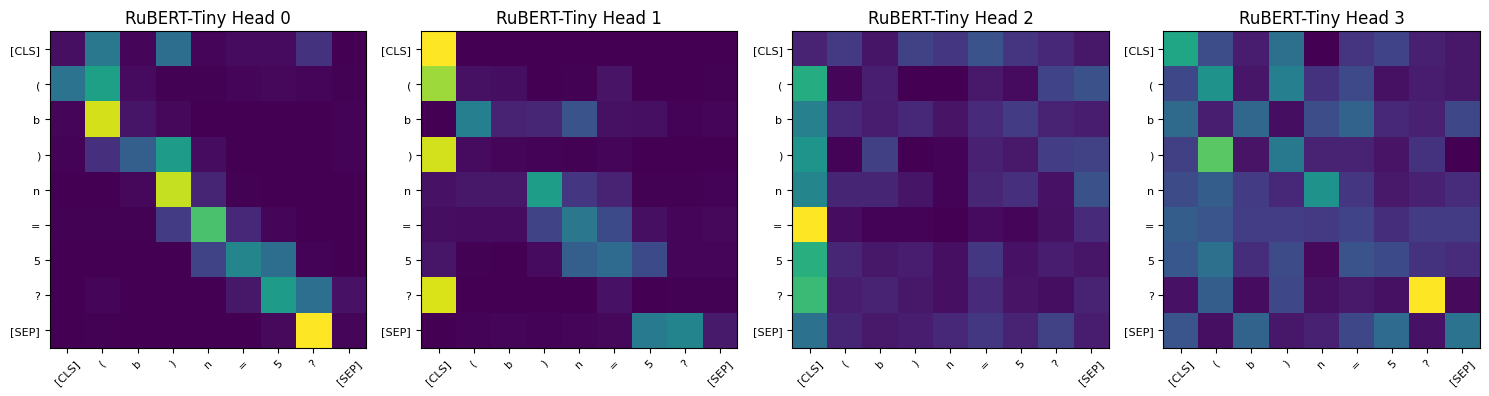

In [79]:
rubert_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
rubert_model = TransformerClassificationModel("cointegrated/rubert-tiny2", num_labels=num_labels)

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(rubert_model.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = rubert_model.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())  # Тоже на CPU

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'RuBERT-Tiny Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()


### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

Анализ дообученнной MathBERT frozen

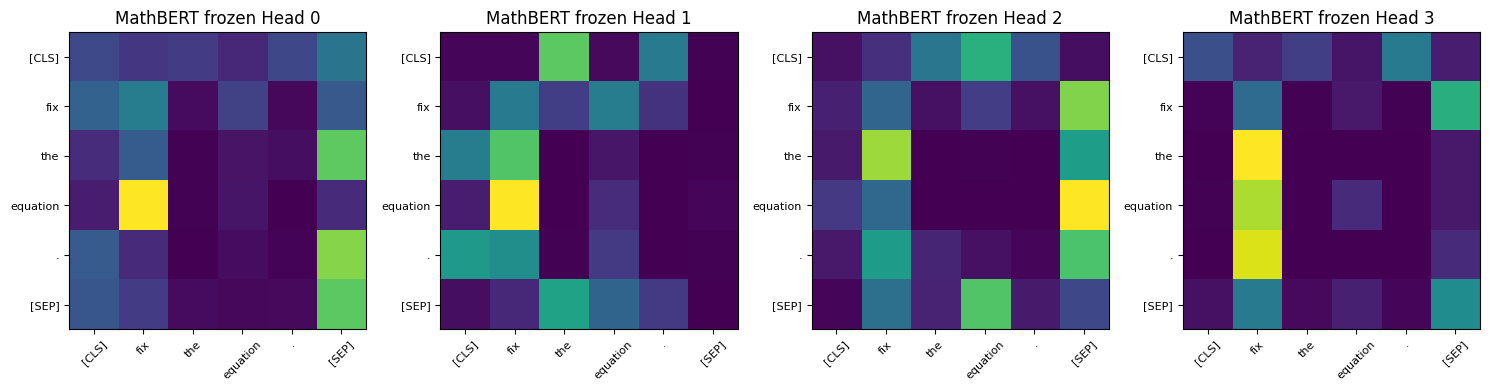

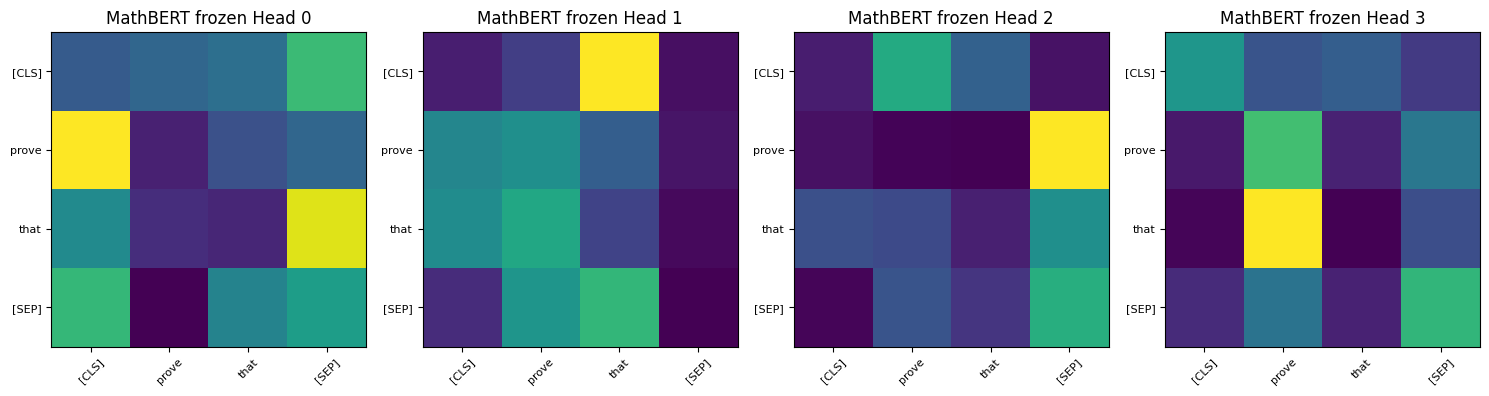

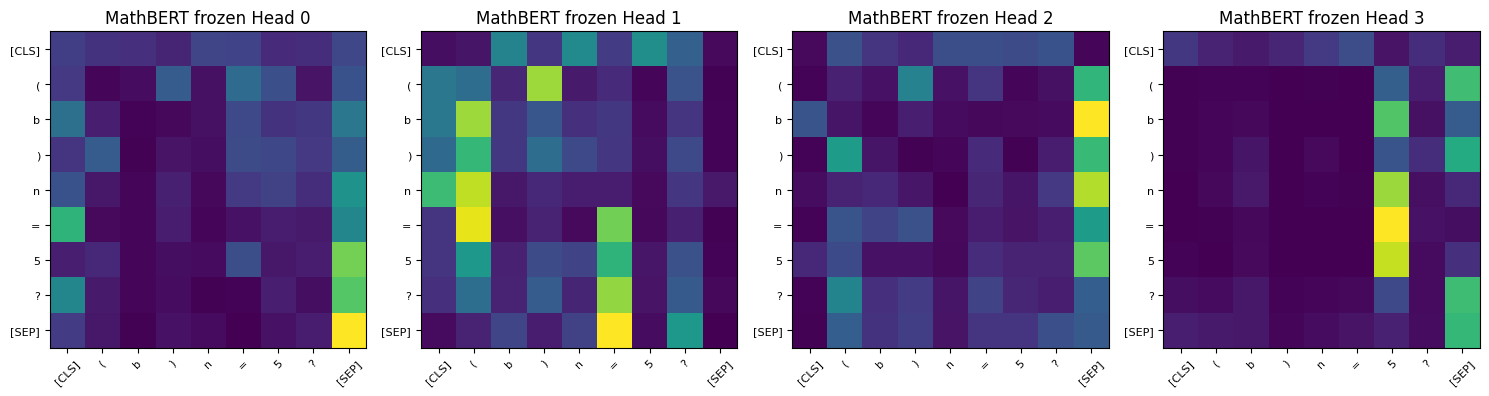

In [85]:
mathbert_tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(mathbert_model_frozen.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = mathbert_model_frozen.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'MathBERT frozen Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()

Анализ дообученнной MathBERT full

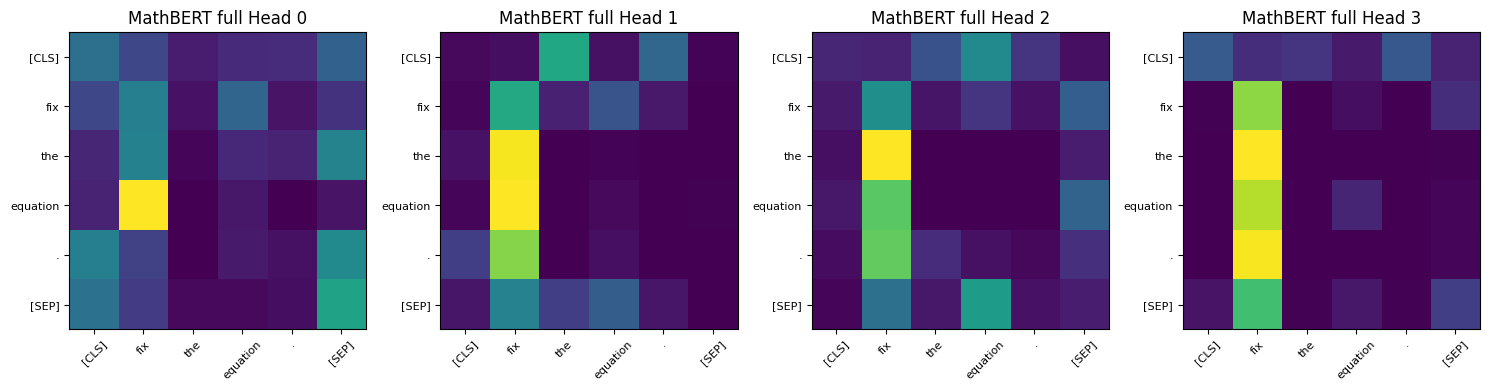

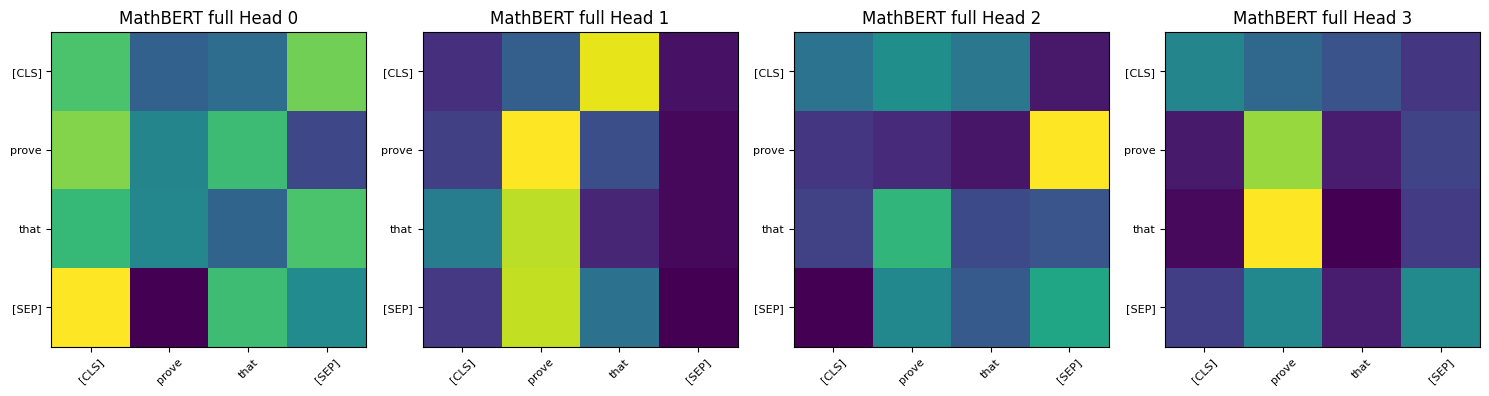

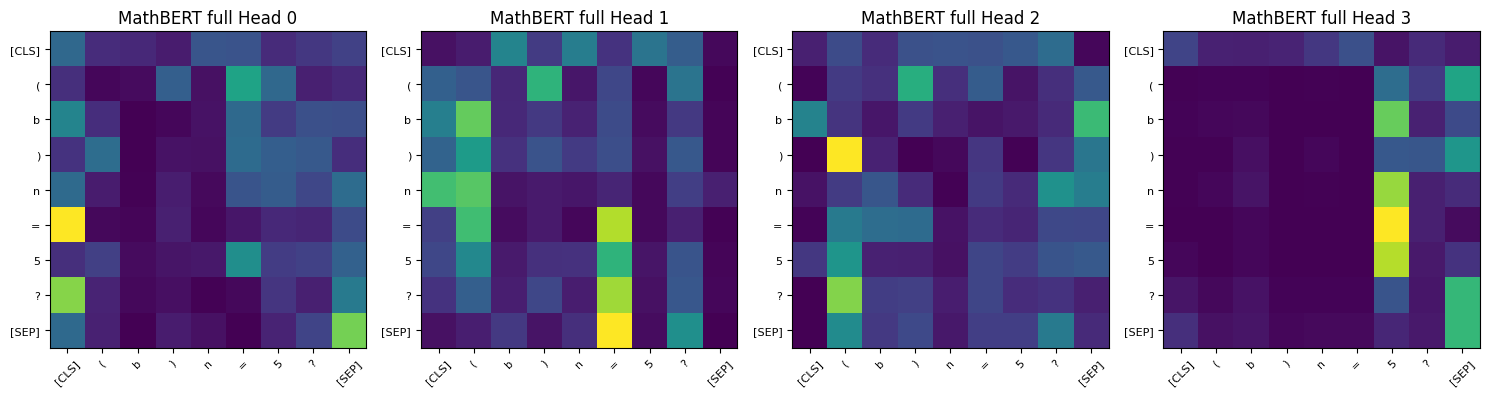

In [87]:
mathbert_tokenizer = AutoTokenizer.from_pretrained("tbs17/MathBERT")

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(mathbert_model_full.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = mathbert_model_full.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'MathBERT full Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()

Анализ дообученнной RuBERT-Tiny frozen

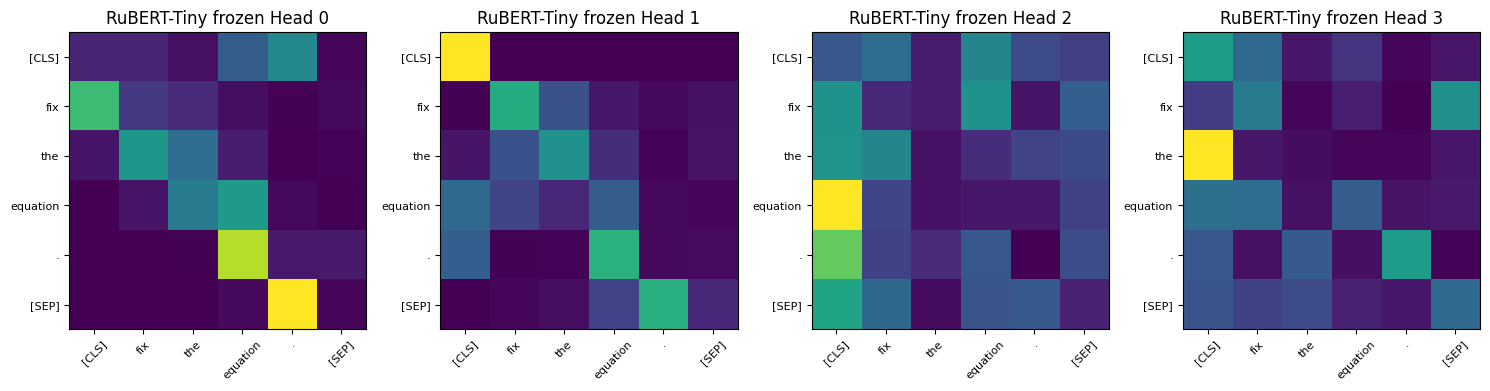

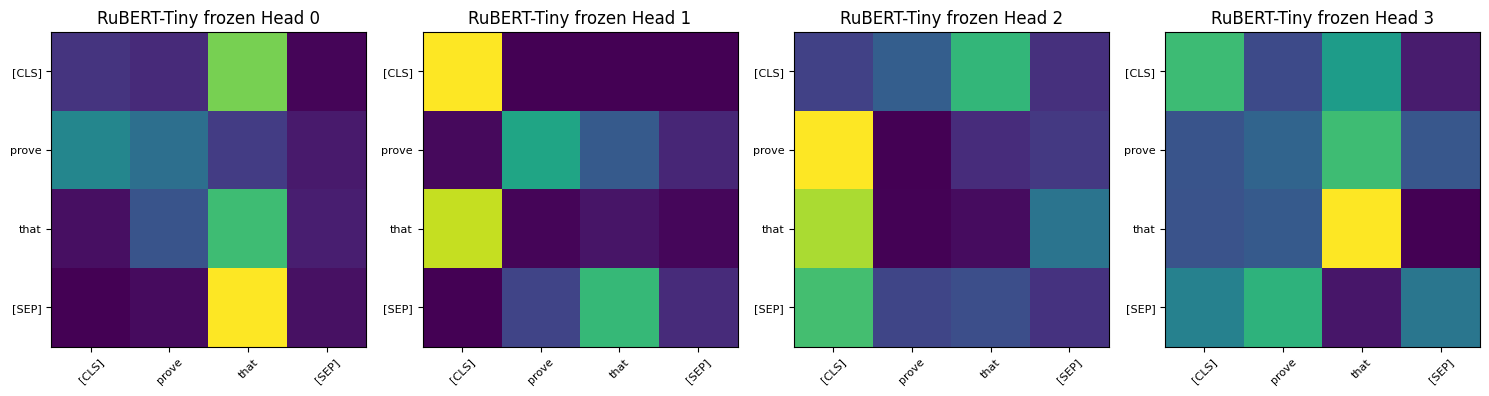

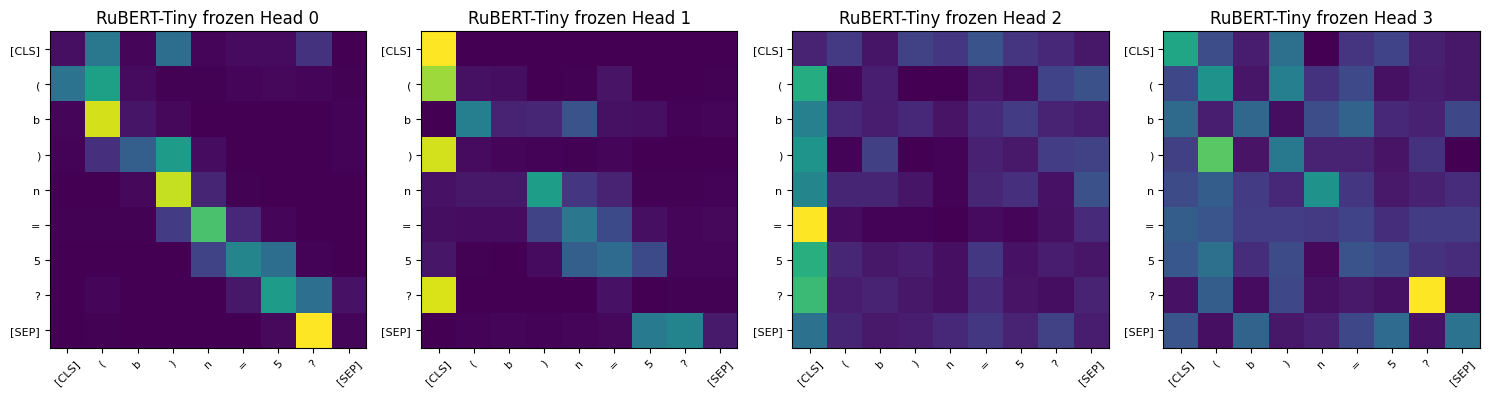

In [91]:
rubert_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(rubert_tiny_transformer_model_frozen.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = rubert_tiny_transformer_model_frozen.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'RuBERT-Tiny frozen Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()


Анализ дообученнной RuBERT-Tiny full

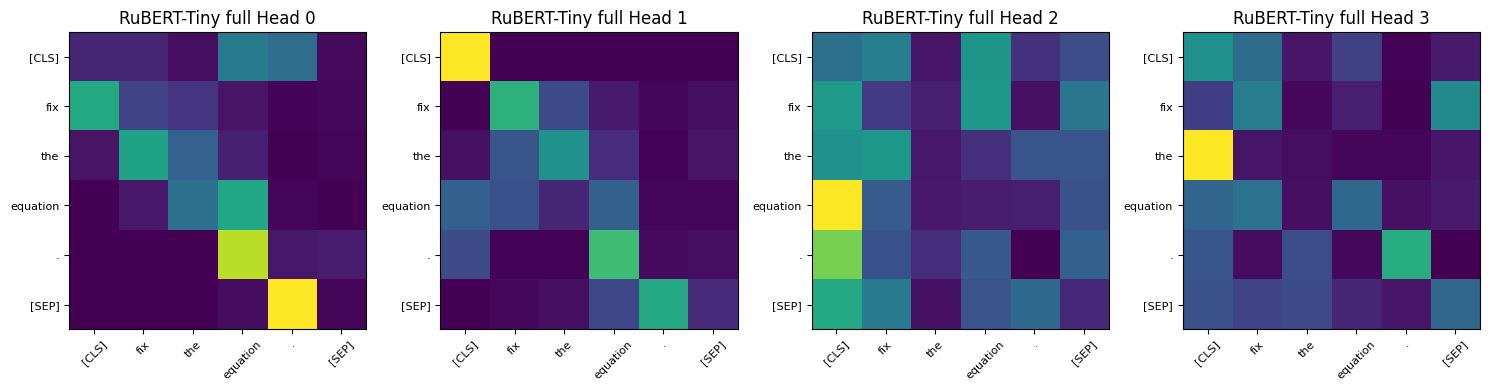

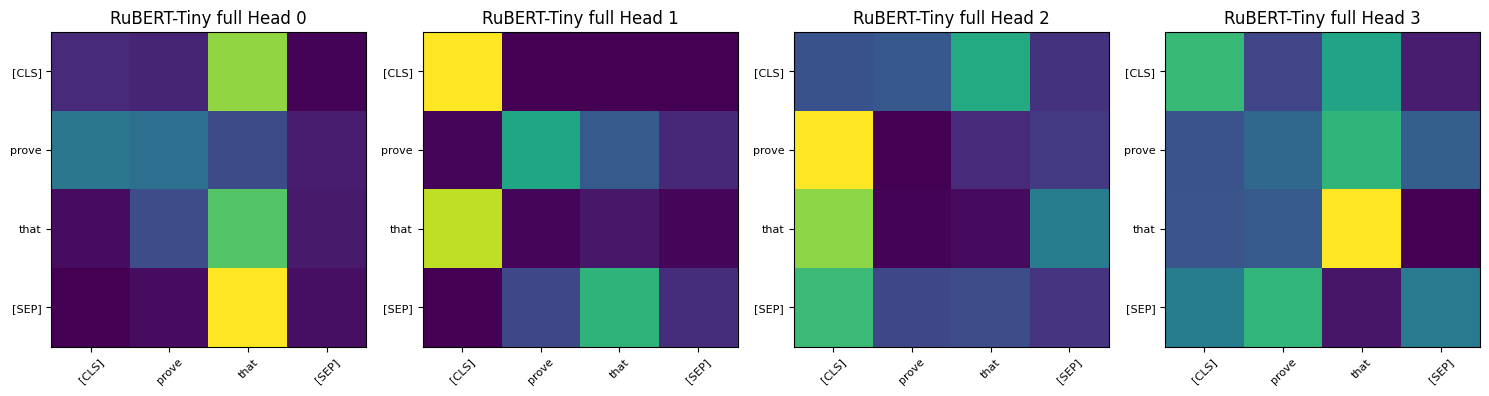

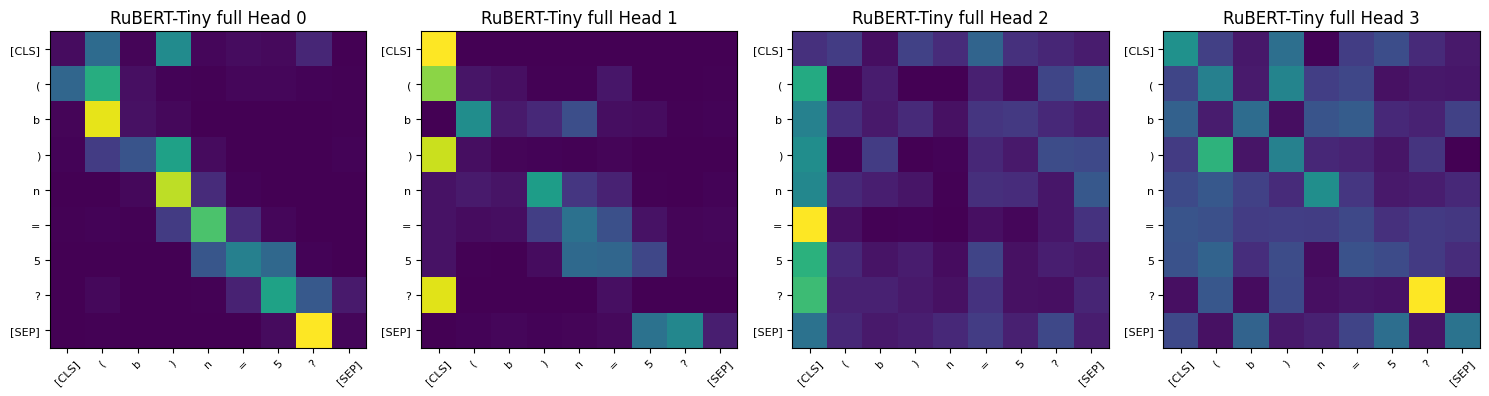

In [90]:
rubert_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

for text in test_texts:
  inputs = mathbert_tokenizer(text, return_tensors="pt", max_length=256, truncation=True)

  device = next(rubert_tiny_transformer_model_full.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  with torch.no_grad():
      outputs = rubert_tiny_transformer_model_full.backbone(inputs['input_ids'], output_attentions=True)
      mathbert_attention = outputs.attentions[0][0].cpu()

  tokens = mathbert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

  plt.figure(figsize=(15, 4))
  for i in range(min(4, mathbert_attention.size(0))):
      plt.subplot(1, 4, i+1)
      plt.imshow(mathbert_attention[i].numpy(), cmap='viridis')
      plt.title(f'RuBERT-Tiny full Head {i}')
      plt.xticks(range(len(tokens)), tokens, rotation=45, fontsize=8)
      plt.yticks(range(len(tokens)), tokens, fontsize=8)
  plt.tight_layout()
  plt.show()


На RuBERT-Tiny видно, что модель не дообученная не видит особенности математического языка (не улавливает связи между аримфитическими знаками), а обученная уже видит зависимости.

Внимание сместилось от общих языковых паттернов к более специализированным математическим конструкциям: усилились связи между переменными и операторами.

Дообученные модели научилась выделять наиболее релевантные для решения математических задач признаки и связи между токенами, что визуально проявляется в более структурированных и осмысленных картах внимания с усиленными связями между математически значимыми элементами текста.